# Week 2 | Know your data

**Objective:** generate the first-impression report before changing the data.
We inspect structure, missing values, duplicates, labels, distributions and relationships
between fields that may contradict their apparent definitions.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Works when opened from the notebook folder, DSV_PROJECT, or repository root.
ROOT = next((p if (p/'Source_Code'/'attrition_lab.py').exists() else p/'DSV_PROJECT'
             for p in [Path.cwd(), *Path.cwd().parents]
             if (p/'Source_Code'/'attrition_lab.py').exists()
             or (p/'DSV_PROJECT'/'Source_Code'/'attrition_lab.py').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Open this notebook inside the DSV_PROJECT workspace.')
sys.path.insert(0, str(ROOT/'Source_Code'))
from attrition_lab import (load_raw, clean_data, quality_report, outlier_report,
                          rate_table, compare, evidence_tables, scenarios,
                          build_artifacts, NUMERIC, MISSING, ORDERS, CONTRASTS)
raw = load_raw()
sns.set_theme(style='whitegrid', palette=['#176B87','#DA7652','#71AFA0','#A18CB8'])
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.titleweight':'bold', 'axes.titlesize':13, 'font.size':10})
FIGURES = ROOT/'Reports'/'Figures'
FIGURES.mkdir(parents=True, exist_ok=True)
def finish(name):
    plt.tight_layout()
    plt.savefig(FIGURES/f'{name}.png', dpi=145, bbox_inches='tight')
    plt.show()
    plt.close()
pd.set_option('display.max_columns', 12)

In [2]:
print(f'Raw shape: {raw.shape[0]:,} rows × {raw.shape[1]} columns')
raw.info()
display(quality_report(raw))
quality_report(raw).to_csv(ROOT/'Reports'/'data_quality_before.csv',index=False)

Raw shape: 74,610 rows × 24 columns
<class 'pandas.DataFrame'>
RangeIndex: 74610 entries, 0 to 74609
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee ID                 74610 non-null  int64  
 1   Age                         74610 non-null  int64  
 2   Gender                      74610 non-null  str    
 3   Years at Company            74610 non-null  int64  
 4   Job Role                    74610 non-null  str    
 5   Monthly Income              74610 non-null  int64  
 6   Work-Life Balance           74610 non-null  str    
 7   Job Satisfaction            74610 non-null  str    
 8   Performance Rating          74610 non-null  str    
 9   Number of Promotions        74610 non-null  int64  
 10  Overtime                    74610 non-null  str    
 11  Distance from Home          72698 non-null  float64
 12  Education Level             74610 non-null  str    
 13  Marita

,column,dtype,missing_count,missing_pct,unique_non_null,constant
0,Employee ID,int64,0,0.000000,74498,False
1,Age,int64,0,0.000000,42,False
2,Gender,str,0,0.000000,2,False
3,Years at Company,int64,0,0.000000,51,False
4,Job Role,str,0,0.000000,5,False
5,Monthly Income,int64,0,0.000000,9836,False
6,Work-Life Balance,str,0,0.000000,4,False
7,Job Satisfaction,str,0,0.000000,4,False
8,Performance Rating,str,0,0.000000,4,False
9,Number of Promotions,int64,0,0.000000,5,False


## Variable types need interpretation

Employee ID is an identifier, not a continuous predictor. Promotions and dependents are counts.
Income and distance are numeric measurements with unverified units. Ordered labels such as
job satisfaction are ordinal, not equally spaced numeric measurements. Job Role contains
sector-like labels (Education, Finance, Healthcare, Media, Technology); retain the source name
without pretending they are specific occupations. The full data dictionary is in `Docs`.

There is no Department field in this dataset. IBM-specific analyses are not carried forward.

In [3]:
categorical = raw.select_dtypes(include=['object','str','string']).columns
for c in categorical:
    print(c, ':', ', '.join(map(str,raw[c].dropna().unique())))
display(raw[NUMERIC].describe().T.round(2))

Gender : Male, Female
Job Role : Education, Media, Healthcare, Technology, Finance
Work-Life Balance : Excellent, Poor, Good, Fair
Job Satisfaction : Medium, High, Very High, Low
Performance Rating : Average, Low, High, Below Average
Overtime : No, Yes
Education Level : Associate Degree, Masterâ€™s Degree, Bachelorâ€™s Degree, High School, PhD
Marital Status : Married, Divorced, Single
Job Level : Mid, Senior, Entry
Company Size : Medium, Small, Large
Remote Work : No, Yes
Leadership Opportunities : No, Yes
Innovation Opportunities : No, Yes
Company Reputation : Excellent, Fair, Poor, Good
Employee Recognition : Medium, Low, High, Very High
Attrition : Stayed, Left


,count,mean,std,min,25%,50%,75%,max
Age,74610.0,38.53,12.08,18.0,28.0,39.0,49.0,59.0
Years at Company,74610.0,15.72,11.22,1.0,7.0,13.0,23.0,51.0
Monthly Income,74610.0,7344.93,2596.37,1226.0,5652.0,7348.5,8876.0,50030.0
Number of Promotions,74610.0,0.83,1.00,0.0,0.0,1.0,2.0,4.0
Distance from Home,72698.0,49.99,28.52,1.0,25.0,50.0,75.0,99.0
Number of Dependents,74610.0,1.66,1.58,0.0,0.0,1.0,3.0,15.0
Company Tenure (In Months),72197.0,55.71,25.39,2.0,36.0,56.0,76.0,128.0


## Missingness and duplicates

Missing values are concentrated in two fields. Check whether missingness is associated
with the outcome before assuming that deleting those rows is harmless. This comparison
does not prove data are missing at random.

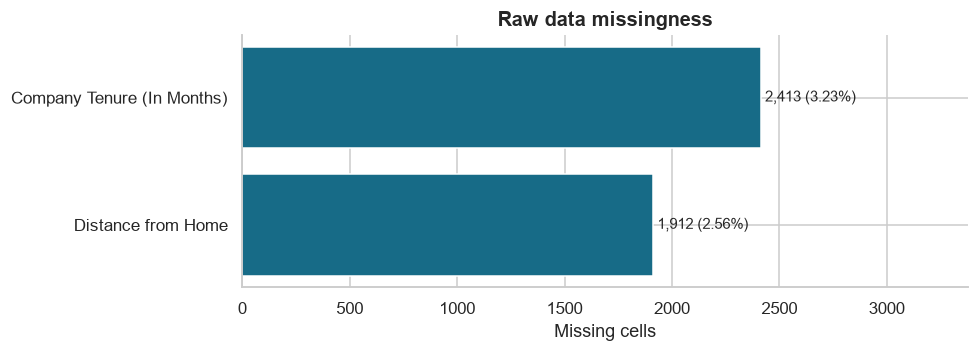

,exact_duplicate_rows,repeated_ID_rows,IDs_after_exact_dedup
0,112,112,74498


,Missing,n,left,left_share_pct,ci_low_pct,ci_high_pct,feature
0,False,72601,34517,47.543422,47.180298,47.906806,Distance from Home
1,True,1897,853,44.965735,42.739573,47.212245,Distance from Home


,Missing,n,left,left_share_pct,ci_low_pct,ci_high_pct,feature
0,False,72117,34480,47.811196,47.446750,48.175874,Company Tenure (In Months)
1,True,2381,890,37.379252,35.457728,39.341436,Company Tenure (In Months)


In [4]:
missing = raw.isna().sum().loc[lambda s:s>0]
fig, ax = plt.subplots(figsize=(9,3.3))
ax.barh(missing.index,missing.values,color='#176B87')
for i,v in enumerate(missing): ax.text(v+20,i,f'{v:,} ({v/len(raw):.2%})',va='center')
ax.set_xlim(0,missing.max()*1.4); ax.set_xlabel('Missing cells'); ax.set_title('Raw data missingness')
finish('02_missingness')
display(pd.DataFrame({'exact_duplicate_rows':[raw.duplicated().sum()],
                       'repeated_ID_rows':[raw['Employee ID'].duplicated().sum()],
                       'IDs_after_exact_dedup':[raw.drop_duplicates()['Employee ID'].nunique()]}))
base = raw.drop_duplicates().assign(Left=lambda d:d.Attrition.eq('Left').astype(int))
for col in MISSING:
    display(rate_table(base.assign(Missing=base[col].isna()),'Missing').assign(feature=col))

## Consistency checks and label repair candidates

An implied starting age below 14 is a **review assumption**, not a proven invalidity rule.
The tenure fields may have different meanings, so a discrepancy greater than 12 months
is flagged for clarification and does not trigger deletion or replacement. Missing tenure
values cannot be compared; their missingness is recorded separately.

Education labels show text-encoding damage. Week 3 explicitly maps only the observed
damaged Bachelor's and Master's labels to readable strings.

In [5]:
audit = clean_data(raw)
flags = ['Early Start Flag','Tenure Definition Review','Income IQR Flag']
display(audit[flags].sum().rename('records_flagged').to_frame())
display(raw['Education Level'].value_counts().to_frame())
display(base.loc[base.Age-base['Years at Company']<14,
                 ['Age','Years at Company','Company Tenure (In Months)']].head(8))

,records_flagged
Early Start Flag,17824
Tenure Definition Review,66049
Income IQR Flag,151


,count
Education Level,
Bachelorâ€™s Degree,22365
Associate Degree,18678
Masterâ€™s Degree,15044
High School,14701
PhD,3822


,Age,Years at Company,Company Tenure (In Months)
0,31,19,89.0
8,57,44,75.0
12,47,38,NaN
13,31,22,NaN
14,40,30,NaN
16,19,9,NaN
18,49,37,NaN
20,51,41,NaN


## First-impression conclusion

This dataset needs duplicate removal, missing-value handling and text repair. It also has
unresolved semantic quality issues. A file with no remaining nulls is not automatically
trustworthy. Preserve an immutable raw copy and document every decision before EDA.